# HW2 – Linear Regression and Regression Trees from Scratch

This notebook implements, trains, and evaluates two regression models **without** any ML library:

| Part | Content |
|---|---|
| 0 | Setup (imports, seeds, output folders) |
| 1 | Synthetic data generator `generate_noisy_dataset` and a fixed 80/20 train/test split |
| 2 | Linear regression via the normal equation: `fit`, `predict`, `evaluate_model` (RMSE) |
| 3 | `RegressionTree` class with recursive binary splits: `fit`, `predict`, `visualize` |
| 4 | Experiments for report questions Q3 – Q7 (linear regression) |
| 5 | Experiments for report questions Q9 – Q11 (regression trees) |
| 6 | Summary of results (saved to `results/results.json`) |

Only `numpy` (linear algebra) and `matplotlib` (plotting) are used. All randomness is seeded, so re-running the notebook reproduces exactly the same datasets, splits, and numbers.

## Part 0 – Setup

In [1]:
import os
import json
import sys

import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# Trees grown down to single records can be deep; raise the recursion limit as a safety margin.
sys.setrecursionlimit(10_000)

# Folders for figures and numeric results (used by the written report).
FIG_DIR = "figures"
RES_DIR = "results"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(RES_DIR, exist_ok=True)

# Global seeds: one for data generation, one for the train/test partition.
DATA_SEED = 42
SPLIT_SEED = 7

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
RESULTS = {}   # collects every number reported in the write-up
print("numpy", np.__version__, "| matplotlib", matplotlib.__version__)

numpy 1.25.2 | matplotlib 3.7.5


## Part 1 – Data Generator

`generate_noisy_dataset(feature_funcs, true_func, x_range, n_samples, noise, seed)`

1. Sample `x ~ Uniform(x_range)` for `n_samples` records.
2. Build the input matrix with columns `x, f_1(x), …, f_d(x)` (the list of extra functions may be empty).
3. Compute the label `y = f(x) + noise`, with `noise ~ Uniform[-ε, ε]`.

It returns `(X, y)`: an `n × (d+1)` input matrix and a label vector, the same layout scikit-learn style models expect.

**Important design choice:** `x` is drawn *before* the noise, and the extra feature functions consume no randomness. So with the same seed, the schemas `(x, y)` and `(x, x², x³, y)` share **identical** `x` and `y` values; only the extra columns differ. Together with a fixed split permutation, every model in this notebook that uses a given (true function, noise level) pair sees exactly the same training and test records.

In [2]:
def generate_noisy_dataset(feature_funcs, true_func, x_range, n_samples, noise, seed=DATA_SEED):
    # Generate a synthetic regression dataset.
    #
    # feature_funcs : list of callables f_i(x) -> extra input columns (may be empty)
    # true_func     : callable f(x), the true (noise-free) function
    # x_range       : (low, high) interval to sample x uniformly from
    # n_samples     : number of records
    # noise         : epsilon; noise ~ Uniform[-epsilon, epsilon] is added to f(x)
    # seed          : RNG seed for reproducibility
    #
    # returns X (n_samples x (1 + len(feature_funcs))) and y (n_samples,)
    rng = np.random.default_rng(seed)
    x = rng.uniform(x_range[0], x_range[1], size=n_samples)        # step 1: sample x
    columns = [x] + [f(x) for f in feature_funcs]                   # step 2: x, f_1(x), ..., f_d(x)
    X = np.column_stack(columns)
    y = true_func(x) + rng.uniform(-noise, noise, size=n_samples)   # step 3: y = f(x) + noise
    return X, y


def train_test_split(X, y, train_frac=0.8, seed=SPLIT_SEED):
    # Split into train/test using a permutation that depends only on the seed and n,
    # so the partitioning is fixed across repeated experiments on the same dataset.
    n = len(y)
    perm = np.random.default_rng(seed).permutation(n)
    n_train = int(round(train_frac * n))
    tr, te = perm[:n_train], perm[n_train:]
    return X[tr], X[te], y[tr], y[te]


# Example from the assignment: extra columns x^2, x^3, true function log(x), x in [0, 1], 10 records, eps = 0.1
X_demo, y_demo = generate_noisy_dataset([lambda x: x**2, lambda x: x**3], np.log, (0.0, 1.0), 10, 0.1)
print("columns: x, x^2, x^3 | y")
for row, label in zip(X_demo[:3], y_demo[:3]):
    print(np.round(row, 4), "|", round(label, 4))

columns: x, x^2, x^3 | y
[0.774  0.599  0.4636] | -0.2821
[0.4389 0.1926 0.0845] | -0.7382
[0.8586 0.7372 0.633 ] | -0.1237


### Experiment configuration

True functions, noise levels, and schemas used throughout the report.

In [3]:
TRUE_FUNCS = {
    "linear": lambda x: 2 * x + 1,
    "cubic":  lambda x: 0.5 * x**3 - x**2 + x,
}
TRUE_FUNC_TEX = {"linear": r"$f(x)=2x+1$", "cubic": r"$f(x)=0.5x^3-x^2+x$"}
NOISE_LEVELS = [0.01, 0.1]
X_RANGE = (0.0, 1.0)
N_SAMPLES = 1000

def monomials(max_degree):
    # Extra feature functions x^2, ..., x^max_degree (x itself is always column 0).
    return [(lambda x, p=p: x**p) for p in range(2, max_degree + 1)]

SCHEMAS = {
    "(x,y)":          [],             # no extra columns
    "(x,x^2,x^3,y)":  monomials(3),   # extra columns x^2 and x^3
}

def make_split(func_name, noise, feature_funcs, n=N_SAMPLES, true_func=None):
    # Generate a dataset and return its fixed 80/20 split.
    f = true_func if true_func is not None else TRUE_FUNCS[func_name]
    X, y = generate_noisy_dataset(feature_funcs, f, X_RANGE, n, noise)
    return train_test_split(X, y)

# Sanity check: both schemas share identical x / y values and identical splits.
a = make_split("cubic", 0.1, SCHEMAS["(x,y)"])
b = make_split("cubic", 0.1, SCHEMAS["(x,x^2,x^3,y)"])
print("same x:", np.allclose(a[0][:, 0], b[0][:, 0]), "| same y_train:", np.allclose(a[2], b[2]),
      "| train/test sizes:", len(a[2]), len(a[3]))

same x: True | same y_train: True | train/test sizes: 800 200


## Part 2 – Linear Regression (normal equation)

**Training – `fit(X, y)`**
1. Build the design matrix by prepending a column of 1s (intercept) to `X`, and the target vector `Y`.
2. Compute $\boldsymbol\beta = (\mathbf X^T\mathbf X)^{-1}\mathbf X^T\mathbf Y$ with numpy.
3. Return the weight vector $\boldsymbol\beta = (\beta_0, \beta_1, \dots, \beta_d)$.

**Prediction – `predict(beta, X)`:** add the same column of 1s, then $\hat y = \mathbf X\boldsymbol\beta$ (one dot product per record).

**Evaluation – `evaluate_model(y_pred, y_true)`:** $\text{RMSE} = \sqrt{\tfrac1n\sum_i (y_i-\hat y_i)^2}$.

In [4]:
def add_intercept(X):
    # Prepend a column of ones so that beta_0 acts as the intercept.
    X = np.asarray(X, dtype=float)
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    return np.column_stack([np.ones(X.shape[0]), X])


def fit(X_train, y_train):
    # Step 1: matrices X (with 1s column) and Y
    Xb = add_intercept(X_train)
    Y = np.asarray(y_train, dtype=float)
    # Step 2: beta = (X^T X)^{-1} X^T Y
    XtX = Xb.T @ Xb
    XtY = Xb.T @ Y
    beta = np.linalg.inv(XtX) @ XtY
    # Step 3: output weight vector
    return beta


def predict(beta, X):
    # y_pred = beta . x for every record (x augmented with the leading 1).
    return add_intercept(X) @ beta


def evaluate_model(y_pred, y_true):
    # Root mean squared error: sqrt(total squared loss / number of records).
    y_pred, y_true = np.asarray(y_pred), np.asarray(y_true)
    return float(np.sqrt(np.sum((y_true - y_pred) ** 2) / len(y_true)))


# Quick correctness check on noise-free data y = 3 + 2x - x^2: should recover [3, 2, -1].
Xc, yc = generate_noisy_dataset([lambda x: x**2], lambda x: 3 + 2*x - x**2, (0, 1), 50, 0.0)
print("recovered beta:", np.round(fit(Xc, yc), 6))

recovered beta: [ 3.  2. -1.]


## Part 3 – Regression Tree

The tree uses recursive binary splits that minimize the sum of squared errors (SSE):

* **`fit(X, y, min_records)`**: calls `build(node_data)` recursively.
  * If a node has fewer than `min_records` records (or cannot be split because all its inputs or all its labels are identical), it becomes a **leaf** that predicts the mean label of its records.
  * Otherwise, for every input column `j` and every threshold `t` halfway between consecutive distinct sorted values, compute
    $\text{SSE}(L) + \text{SSE}(R)$ for $L=\{x_j \le t\}$, $R=\{x_j>t\}$. Using prefix sums makes this $O(n)$ per column after sorting, via $\text{SSE}=\sum y^2-(\sum y)^2/n$.
  * Choose the (column, threshold) pair with the smallest total SSE, split, and recurse on both children.
* **`predict(X)`**: route each record from the root down (go left if $x_j \le t$) and return the leaf mean.
* **`visualize(...)`**: plots the piecewise-constant prediction over the x-range and draws a vertical line at every split point (splits on $x^2$ or $x^3$ are mapped back to the x-axis).

In [5]:
class Node:
    # One tree node. Internal nodes store (feature, threshold, left, right); leaves store value.
    def __init__(self, n_records, value):
        self.n_records = n_records     # number of training records that reached this node
        self.value = value             # mean label (the prediction if this is a leaf)
        self.feature = None            # index of split column
        self.threshold = None          # split threshold: left if x[feature] <= threshold
        self.left = None
        self.right = None

    @property
    def is_leaf(self):
        return self.left is None


class RegressionTree:
    def __init__(self):
        self.root = None
        self.min_records = None

    # ---------- training ----------
    def fit(self, X, y, min_records):
        # Build the tree. A node is split only if it holds at least min_records records.
        X = np.asarray(X, dtype=float)
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        self.min_records = min_records
        self.root = self._build(X, np.asarray(y, dtype=float))
        return self

    def _build(self, X, y):
        node = Node(len(y), float(np.mean(y)))
        # Stopping rule: too few records -> leaf
        if len(y) < self.min_records or len(y) < 2:
            return node
        split = self._best_split(X, y)
        if split is None:              # no valid split (all x identical or all y identical)
            return node
        j, t = split
        mask = X[:, j] <= t
        node.feature, node.threshold = j, t
        node.left = self._build(X[mask], y[mask])     # recurse on left part
        node.right = self._build(X[~mask], y[~mask])  # recurse on right part
        return node

    @staticmethod
    def _best_split(X, y):
        # Return (feature, threshold) minimizing SSE(left) + SSE(right), or None.
        if np.all(y == y[0]):
            return None
        n = len(y)
        best_sse, best = np.inf, None
        for j in range(X.shape[1]):
            order = np.argsort(X[:, j], kind="mergesort")
            xs, ys = X[order, j], y[order]
            # prefix sums of y and y^2 -> SSE of every left/right partition in O(n)
            cs, cs2 = np.cumsum(ys), np.cumsum(ys ** 2)
            n_left = np.arange(1, n)                    # left part = first k records, k = 1..n-1
            sum_l, sum2_l = cs[:-1], cs2[:-1]
            sum_r, sum2_r = cs[-1] - sum_l, cs2[-1] - sum2_l
            sse = (sum2_l - sum_l**2 / n_left) + (sum2_r - sum_r**2 / (n - n_left))
            valid = xs[:-1] < xs[1:]                    # can only cut between distinct x values
            if not np.any(valid):
                continue
            sse = np.where(valid, sse, np.inf)
            k = int(np.argmin(sse))
            if sse[k] < best_sse - 1e-12:
                best_sse = sse[k]
                best = (j, 0.5 * (xs[k] + xs[k + 1]))   # threshold halfway between neighbours
        return best

    # ---------- prediction ----------
    def predict(self, X):
        X = np.asarray(X, dtype=float)
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        return np.array([self._predict_one(row) for row in X])

    def _predict_one(self, row):
        node = self.root
        while not node.is_leaf:
            node = node.left if row[node.feature] <= node.threshold else node.right
        return node.value

    # ---------- inspection ----------
    def _nodes(self):
        stack, out = [self.root], []
        while stack:
            node = stack.pop()
            out.append(node)
            if not node.is_leaf:
                stack += [node.left, node.right]
        return out

    def n_nodes(self):
        return len(self._nodes())

    def leaf_sizes(self):
        return [nd.n_records for nd in self._nodes() if nd.is_leaf]

    def depth(self, node=None):
        node = node or self.root
        return 0 if node.is_leaf else 1 + max(self.depth(node.left), self.depth(node.right))

    def split_points(self):
        return [(nd.feature, nd.threshold) for nd in self._nodes() if not nd.is_leaf]

    # ---------- visualization ----------
    def visualize(self, ax=None, x_range=(0.0, 1.0), feature_funcs=(), n_grid=4000,
                  color="C3", label="tree prediction", show_splits=True):
        # Plot the tree's prediction over x_range and mark all split points.
        # feature_funcs must be the same extra columns used for training, so the grid
        # can be expanded to (x, f_1(x), ...). Splits on f_i(x) are mapped back to x
        # by interpolation (valid because x^2, x^3 are monotone on [0, 1]).
        if ax is None:
            ax = plt.gca()
        xg = np.linspace(x_range[0], x_range[1], n_grid)
        Xg = np.column_stack([xg] + [f(xg) for f in feature_funcs])
        ax.step(xg, self.predict(Xg), where="mid", color=color, lw=1.6, label=label, zorder=4)
        if show_splits:
            xs = []
            for j, t in self.split_points():
                xs.append(t if j == 0 else float(np.interp(t, Xg[:, j], xg)))
            for i, xv in enumerate(xs):
                ax.axvline(xv, color="gray", lw=0.6 if len(xs) < 50 else 0.15, alpha=0.6,
                           ls="--", zorder=1, label="split points" if i == 0 else None)
        return ax


# Sanity check on a step function: one split at x = 0.5 should be found.
Xs = np.linspace(0, 1, 101).reshape(-1, 1); ys = (Xs[:, 0] > 0.5).astype(float)
t = RegressionTree().fit(Xs, ys, min_records=50)
print("splits:", t.split_points(), "| nodes:", t.n_nodes(), "| leaf sizes:", t.leaf_sizes())

splits: [(0, 0.505)] | nodes: 3 | leaf sizes: [50, 51]


## Part 4 – Linear-Regression Experiments

### Q3 & Q4 – Schemas (x, y) and (x, x², x³, y), true functions linear / cubic, noise 0.01 / 0.1, n = 1000

For every combination we train on the 80 % split, evaluate RMSE on train and test, and plot:
the training scatter, the true function, and the **entire** learned function
$\hat f(x)=\beta_0+\beta_1x(+\beta_2x^2+\beta_3x^3)$.

(x,y)           linear eps=0.01  train=0.00580 test=0.00574  model: +1.0002 +2.0001x
(x,y)           linear eps=0.1   train=0.05796 test=0.05739  model: +1.0024 +2.0006x
(x,y)           cubic  eps=0.01  train=0.02149 test=0.02214  model: +0.0661 +0.4515x
(x,y)           cubic  eps=0.1   train=0.06142 test=0.06287  model: +0.0682 +0.4520x


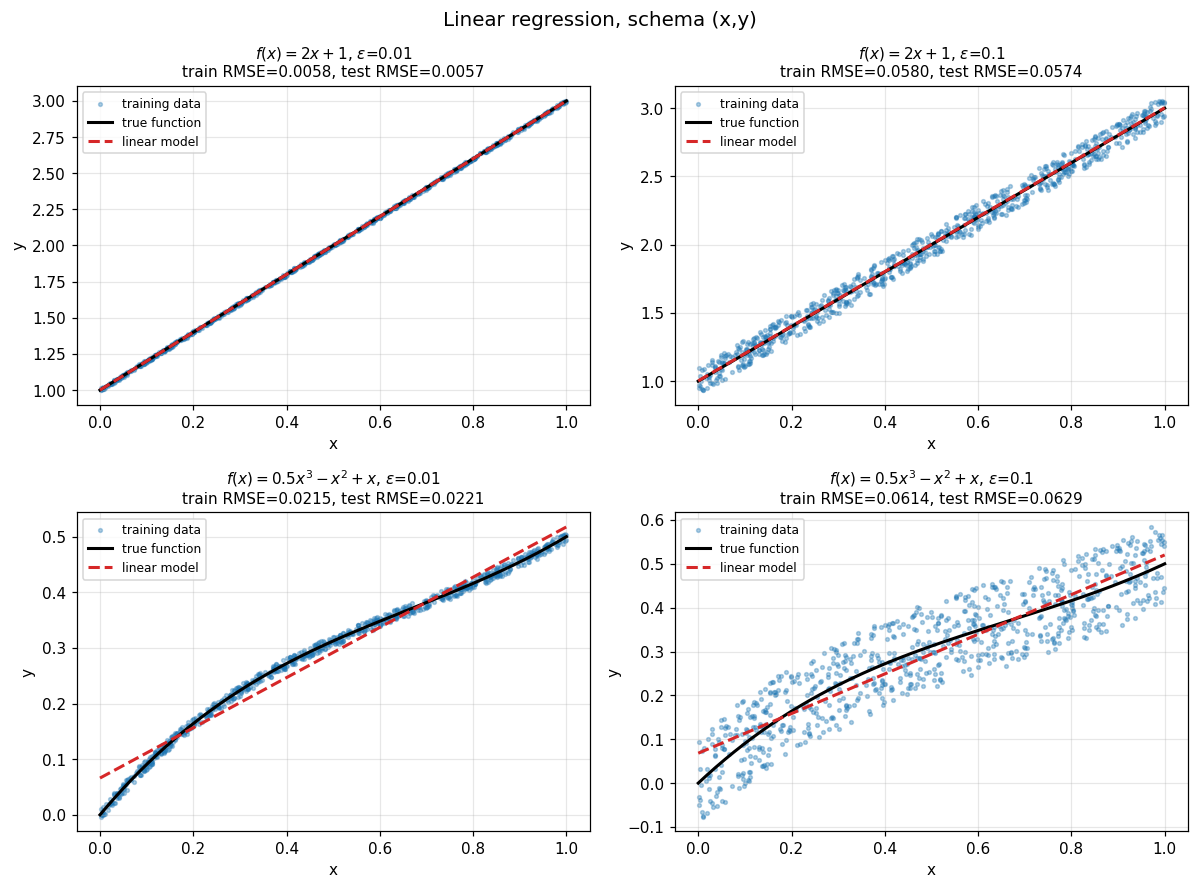

(x,x^2,x^3,y)   linear eps=0.01  train=0.00579 test=0.00574  model: +0.9999 +2.0059x -0.0179x^2 +0.0135x^3
(x,x^2,x^3,y)   linear eps=0.1   train=0.05788 test=0.05744  model: +0.9994 +2.0587x -0.1793x^2 +0.1350x^3
(x,x^2,x^3,y)   cubic  eps=0.01  train=0.00579 test=0.00574  model: -0.0001 +1.0059x -1.0179x^2 +0.5135x^3
(x,x^2,x^3,y)   cubic  eps=0.1   train=0.05788 test=0.05744  model: -0.0006 +1.0587x -1.1793x^2 +0.6350x^3


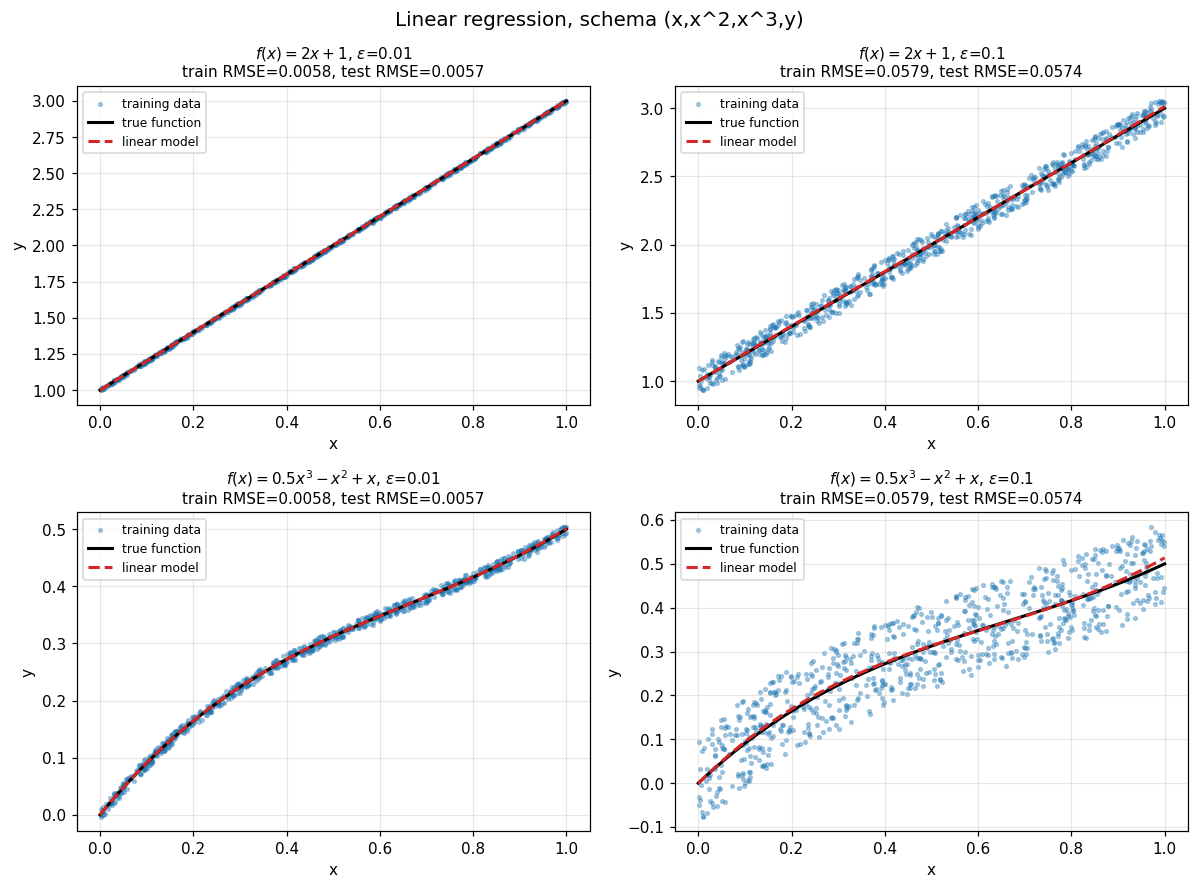

In [6]:
def poly_string(beta):
    terms = [f"{beta[0]:+.4f}"] + [f"{b:+.4f}x" + (f"^{i}" if i > 1 else "") for i, b in enumerate(beta[1:], 1)]
    return " ".join(terms)

lin_results = {}   # key: (schema, func, noise) -> dict with beta and RMSEs
for schema, feats in SCHEMAS.items():
    fig, axes = plt.subplots(2, 2, figsize=(11, 8.2))
    for r, func_name in enumerate(TRUE_FUNCS):
        for c, eps in enumerate(NOISE_LEVELS):
            Xtr, Xte, ytr, yte = make_split(func_name, eps, feats)
            beta = fit(Xtr, ytr)
            rmse_tr = evaluate_model(predict(beta, Xtr), ytr)
            rmse_te = evaluate_model(predict(beta, Xte), yte)
            lin_results[(schema, func_name, eps)] = dict(beta=beta.tolist(), train_rmse=rmse_tr, test_rmse=rmse_te)

            ax = axes[r, c]
            xg = np.linspace(*X_RANGE, 400)
            Xg = np.column_stack([xg] + [f(xg) for f in feats])
            ax.scatter(Xtr[:, 0], ytr, s=6, alpha=0.35, label="training data")
            ax.plot(xg, TRUE_FUNCS[func_name](xg), "k-", lw=2, label="true function")
            ax.plot(xg, predict(beta, Xg), "C3--", lw=2, label="linear model")
            ax.set_title(f"{TRUE_FUNC_TEX[func_name]}, $\\epsilon$={eps}\n"
                         f"train RMSE={rmse_tr:.4f}, test RMSE={rmse_te:.4f}", fontsize=10)
            ax.set_xlabel("x"); ax.set_ylabel("y")
            ax.legend(fontsize=8, loc="best")
            print(f"{schema:15s} {func_name:6s} eps={eps:<5} train={rmse_tr:.5f} test={rmse_te:.5f}  "
                  f"model: {poly_string(beta)}")
    fig.suptitle(f"Linear regression, schema {schema}", fontsize=13)
    fig.tight_layout()
    tag = "q3_lr_xy" if schema == "(x,y)" else "q4_lr_xx2x3"
    fig.savefig(f"{FIG_DIR}/{tag}.png", dpi=150, bbox_inches="tight")
    plt.show()

### Q5 – Extrapolation to x = 10

The true values are $f(10)=21$ (linear) and $f(10)=0.5\cdot1000-100+10=410$ (cubic). We predict at $x=10$ (with $x^2=100$, $x^3=1000$ for the extended schema) and report the error $\hat y - f(10)$.

In [7]:
extrap = {}
print(f"{'schema':15s} {'func':6s} {'eps':5s} {'f(10)':>8s} {'pred':>10s} {'error':>10s}")
for (schema, func_name, eps), res in lin_results.items():
    x10 = np.array([[10.0] + [f(10.0) for f in SCHEMAS[schema]]])
    pred = float(predict(np.array(res["beta"]), x10)[0])
    true = float(TRUE_FUNCS[func_name](10.0))
    extrap[(schema, func_name, eps)] = dict(true=true, pred=pred, error=pred - true)
    print(f"{schema:15s} {func_name:6s} {eps:<5} {true:8.2f} {pred:10.3f} {pred-true:10.3f}")

schema          func   eps      f(10)       pred      error
(x,y)           linear 0.01     21.00     21.001      0.001
(x,y)           linear 0.1      21.00     21.008      0.008
(x,y)           cubic  0.01    410.00      4.581   -405.419
(x,y)           cubic  0.1     410.00      4.588   -405.412
(x,x^2,x^3,y)   linear 0.01     21.00     32.767     11.767
(x,x^2,x^3,y)   linear 0.1      21.00    138.667    117.667
(x,x^2,x^3,y)   cubic  0.01    410.00    421.767     11.767
(x,x^2,x^3,y)   cubic  0.1     410.00    527.667    117.667


### Q6 – Optimal model and irreducible error

* The **optimal model** (lowest expected squared error) is $E[y\mid x]$. The noise is uniform on $[-\epsilon,\epsilon]$ and has mean 0, so $E[y\mid x]=f(x)$: the optimal model *is the true function*.
* The **irreducible error** is the error the optimal model still makes, i.e. the noise. For $U[-\epsilon,\epsilon]$, $\operatorname{Var}=\epsilon^2/3$, so the minimum expected RMSE is $\epsilon/\sqrt3$: $0.00577$ for $\epsilon=0.01$ and $0.0577$ for $\epsilon=0.1$.
  We also report the *empirical* irreducible error on each test set, i.e. the RMSE of the true $f$ itself.

In [8]:
irreducible = {}
print(f"{'func':6s} {'eps':5s} {'eps/sqrt3':>10s} {'RMSE(f,test)':>13s} | test RMSE (x,y)  (x,x2,x3,y)")
for func_name in TRUE_FUNCS:
    for eps in NOISE_LEVELS:
        Xtr, Xte, ytr, yte = make_split(func_name, eps, [])
        emp = evaluate_model(TRUE_FUNCS[func_name](Xte[:, 0]), yte)
        irreducible[(func_name, eps)] = dict(theory=eps / np.sqrt(3), empirical_test=emp)
        print(f"{func_name:6s} {eps:<5} {eps/np.sqrt(3):10.5f} {emp:13.5f} | "
              f"{lin_results[('(x,y)', func_name, eps)]['test_rmse']:.5f}          "
              f"{lin_results[('(x,x^2,x^3,y)', func_name, eps)]['test_rmse']:.5f}")

func   eps    eps/sqrt3  RMSE(f,test) | test RMSE (x,y)  (x,x2,x3,y)
linear 0.01     0.00577       0.00572 | 0.00574          0.00574
linear 0.1      0.05774       0.05723 | 0.05739          0.05744
cubic  0.01     0.00577       0.00572 | 0.02214          0.00574
cubic  0.1      0.05774       0.05723 | 0.06287          0.05744


### Q7 – Adding higher-order monomials (cubic, ε = 0.1, n = 1000)

Schemas $(x,y), (x,x^2,y), \dots, (x,x^2,\dots,x^{10},y)$: same records and same split each time; only the columns change.

degree  1: train RMSE=0.061422  test RMSE=0.062867  cond(X^T X)=1.9e+01
degree  2: train RMSE=0.059072  test RMSE=0.058926  cond(X^T X)=5.2e+02
degree  3: train RMSE=0.057882  test RMSE=0.057440  cond(X^T X)=1.6e+04
degree  4: train RMSE=0.057880  test RMSE=0.057437  cond(X^T X)=4.6e+05
degree  5: train RMSE=0.057873  test RMSE=0.057352  cond(X^T X)=1.4e+07
degree  6: train RMSE=0.057821  test RMSE=0.057094  cond(X^T X)=4.6e+08
degree  7: train RMSE=0.057807  test RMSE=0.057090  cond(X^T X)=1.5e+10
degree  8: train RMSE=0.057806  test RMSE=0.057036  cond(X^T X)=4.8e+11
degree  9: train RMSE=0.057761  test RMSE=0.057140  cond(X^T X)=1.5e+13
degree 10: train RMSE=0.057754  test RMSE=0.057069  cond(X^T X)=5.0e+14


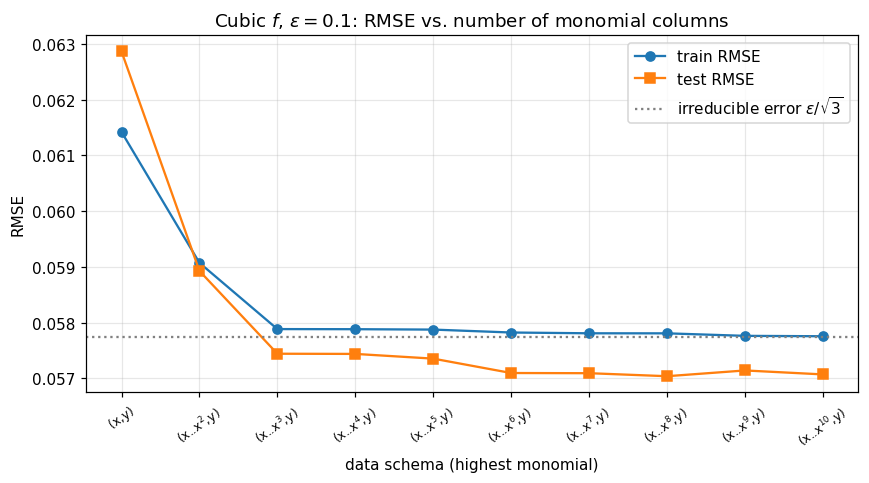

In [9]:
degrees = list(range(1, 11))
q7_train, q7_test = [], []
for d in degrees:
    Xtr, Xte, ytr, yte = make_split("cubic", 0.1, monomials(d))
    beta = fit(Xtr, ytr)
    q7_train.append(evaluate_model(predict(beta, Xtr), ytr))
    q7_test.append(evaluate_model(predict(beta, Xte), yte))
    print(f"degree {d:2d}: train RMSE={q7_train[-1]:.6f}  test RMSE={q7_test[-1]:.6f}  cond(X^T X)={np.linalg.cond(add_intercept(Xtr).T @ add_intercept(Xtr)):.1e}")

fig, ax = plt.subplots(figsize=(8, 4.5))
labels = ["(x,y)"] + [f"(x..x$^{{{d}}}$,y)" for d in degrees[1:]]
ax.plot(degrees, q7_train, "o-", label="train RMSE")
ax.plot(degrees, q7_test, "s-", label="test RMSE")
ax.axhline(0.1 / np.sqrt(3), color="gray", ls=":", label=r"irreducible error $\epsilon/\sqrt{3}$")
ax.set_xticks(degrees); ax.set_xticklabels(labels, rotation=35, fontsize=8)
ax.set_xlabel("data schema (highest monomial)"); ax.set_ylabel("RMSE")
ax.set_title(r"Cubic $f$, $\epsilon=0.1$: RMSE vs. number of monomial columns")
ax.legend(); fig.tight_layout()
fig.savefig(f"{FIG_DIR}/q7_monomials.png", dpi=150, bbox_inches="tight")
plt.show()

## Part 5 – Regression-Tree Experiments

### Q9 – Same datasets/splits as linear regression; min_records ∈ {1000, 50, 1}

One figure per (true function, noise) pair. Rows are schemas and columns are `min_records`. Each panel shows the training data, the true function, the tree prediction, and the split points (dashed).

linear eps=0.01  (x,y)           min_rec=1000  nodes=    1 leaves=   1 depth=  0 leaf size [800,800] train=0.57854 test=0.60050 split cols=[]
linear eps=0.01  (x,y)           min_rec=50    nodes=   53 leaves=  27 depth=  5 leaf size [19,47] train=0.02332 test=0.02530 split cols=[0]
linear eps=0.01  (x,y)           min_rec=1     nodes= 1599 leaves= 800 depth= 15 leaf size [1,1] train=0.00000 test=0.00803 split cols=[0]
linear eps=0.01  (x,x^2,x^3,y)   min_rec=1000  nodes=    1 leaves=   1 depth=  0 leaf size [800,800] train=0.57854 test=0.60050 split cols=[]
linear eps=0.01  (x,x^2,x^3,y)   min_rec=50    nodes=   53 leaves=  27 depth=  5 leaf size [19,47] train=0.02332 test=0.02530 split cols=[0]
linear eps=0.01  (x,x^2,x^3,y)   min_rec=1     nodes= 1599 leaves= 800 depth= 15 leaf size [1,1] train=0.00000 test=0.00803 split cols=[0]


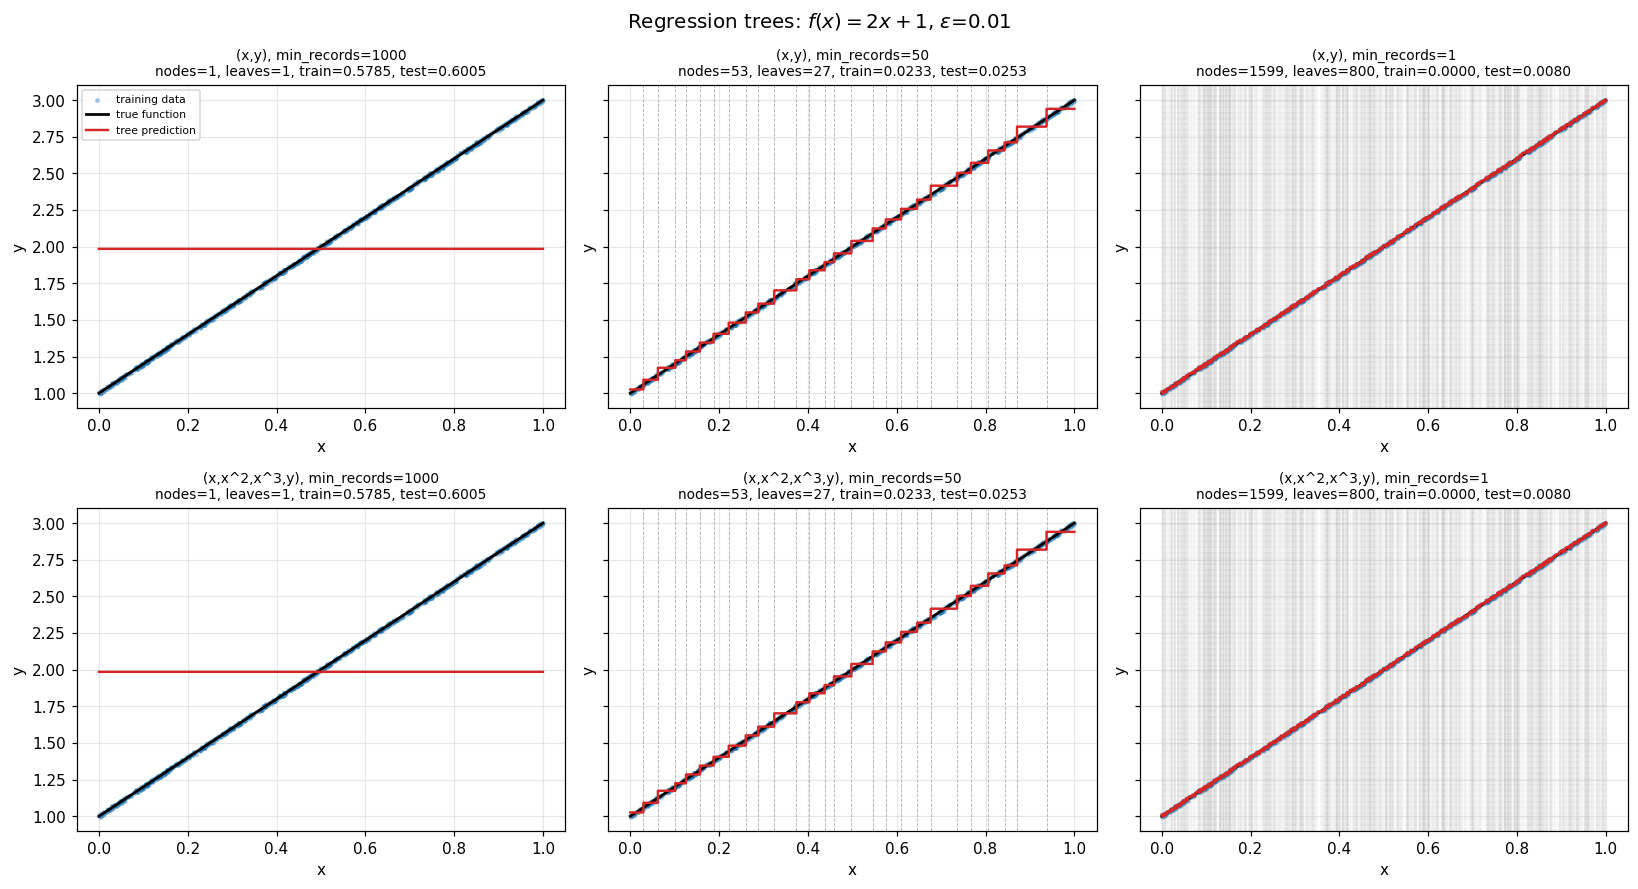

linear eps=0.1   (x,y)           min_rec=1000  nodes=    1 leaves=   1 depth=  0 leaf size [800,800] train=0.58155 test=0.60300 split cols=[]
linear eps=0.1   (x,y)           min_rec=50    nodes=   47 leaves=  24 depth=  5 leaf size [12,49] train=0.05543 test=0.06361 split cols=[0]
linear eps=0.1   (x,y)           min_rec=1     nodes= 1599 leaves= 800 depth= 17 leaf size [1,1] train=0.00000 test=0.07879 split cols=[0]
linear eps=0.1   (x,x^2,x^3,y)   min_rec=1000  nodes=    1 leaves=   1 depth=  0 leaf size [800,800] train=0.58155 test=0.60300 split cols=[]
linear eps=0.1   (x,x^2,x^3,y)   min_rec=50    nodes=   47 leaves=  24 depth=  5 leaf size [12,49] train=0.05543 test=0.06361 split cols=[0]
linear eps=0.1   (x,x^2,x^3,y)   min_rec=1     nodes= 1599 leaves= 800 depth= 17 leaf size [1,1] train=0.00000 test=0.07879 split cols=[0]


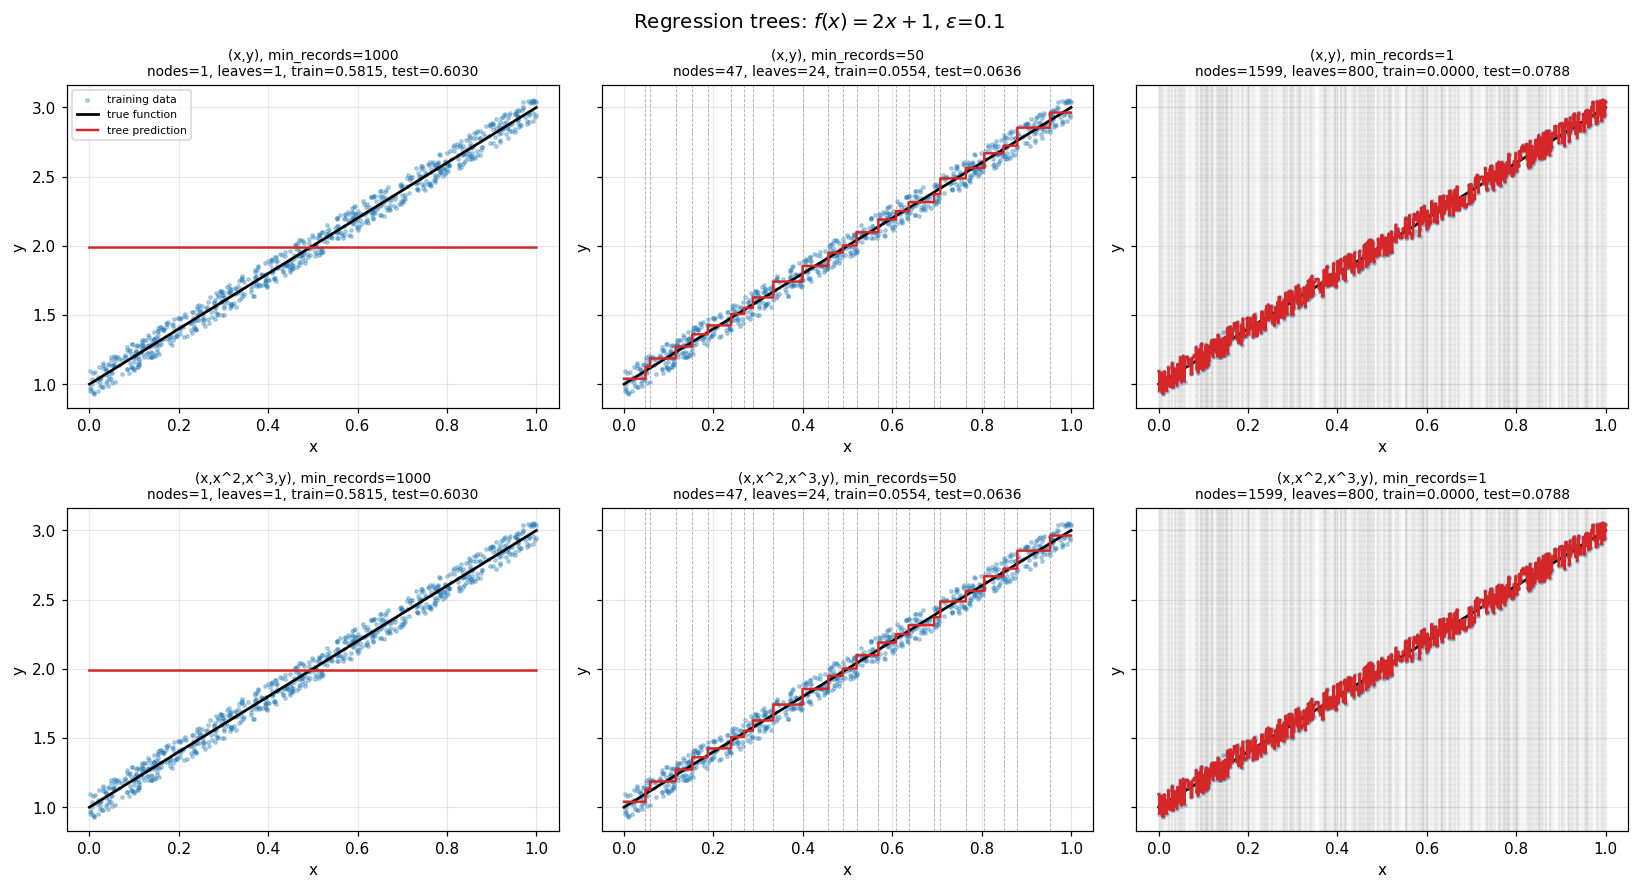

cubic  eps=0.01  (x,y)           min_rec=1000  nodes=    1 leaves=   1 depth=  0 leaf size [800,800] train=0.13234 test=0.13685 split cols=[]
cubic  eps=0.01  (x,y)           min_rec=50    nodes=   49 leaves=  25 depth=  6 leaf size [15,45] train=0.00759 test=0.00873 split cols=[0]
cubic  eps=0.01  (x,y)           min_rec=1     nodes= 1599 leaves= 800 depth= 16 leaf size [1,1] train=0.00000 test=0.00788 split cols=[0]
cubic  eps=0.01  (x,x^2,x^3,y)   min_rec=1000  nodes=    1 leaves=   1 depth=  0 leaf size [800,800] train=0.13234 test=0.13685 split cols=[]
cubic  eps=0.01  (x,x^2,x^3,y)   min_rec=50    nodes=   49 leaves=  25 depth=  6 leaf size [15,45] train=0.00759 test=0.00873 split cols=[0]
cubic  eps=0.01  (x,x^2,x^3,y)   min_rec=1     nodes= 1599 leaves= 800 depth= 16 leaf size [1,1] train=0.00000 test=0.00788 split cols=[0]


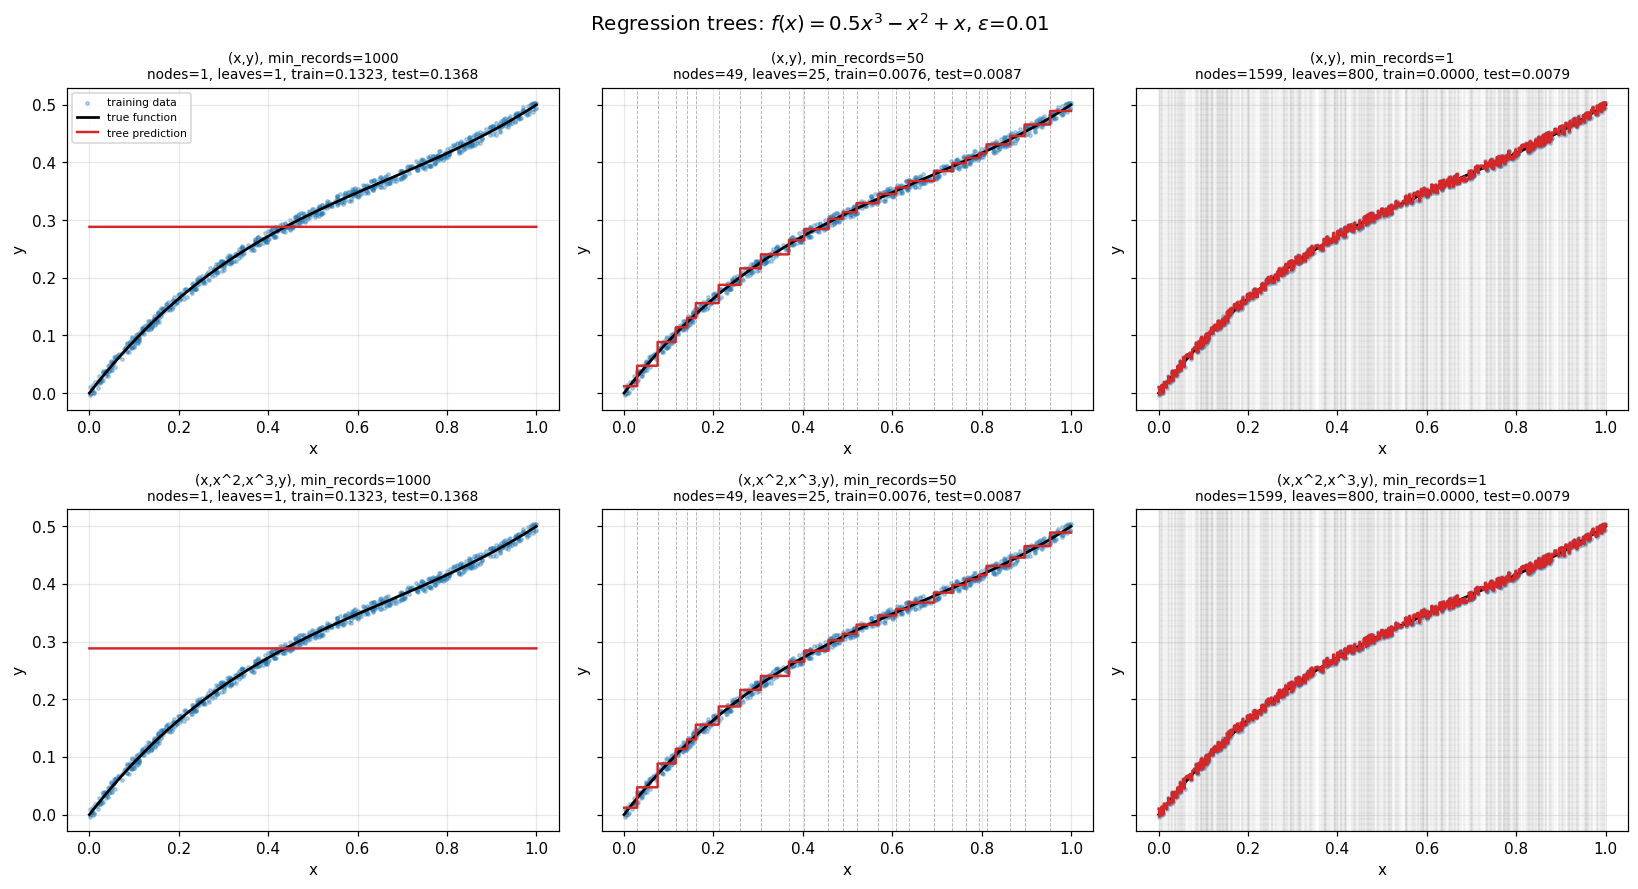

cubic  eps=0.1   (x,y)           min_rec=1000  nodes=    1 leaves=   1 depth=  0 leaf size [800,800] train=0.14444 test=0.14877 split cols=[]
cubic  eps=0.1   (x,y)           min_rec=50    nodes=   73 leaves=  37 depth=  9 leaf size [1,49] train=0.05294 test=0.06155 split cols=[0]
cubic  eps=0.1   (x,y)           min_rec=1     nodes= 1599 leaves= 800 depth= 22 leaf size [1,1] train=0.00000 test=0.07883 split cols=[0]
cubic  eps=0.1   (x,x^2,x^3,y)   min_rec=1000  nodes=    1 leaves=   1 depth=  0 leaf size [800,800] train=0.14444 test=0.14877 split cols=[]
cubic  eps=0.1   (x,x^2,x^3,y)   min_rec=50    nodes=   73 leaves=  37 depth=  9 leaf size [1,49] train=0.05294 test=0.06155 split cols=[0]
cubic  eps=0.1   (x,x^2,x^3,y)   min_rec=1     nodes= 1599 leaves= 800 depth= 22 leaf size [1,1] train=0.00000 test=0.07883 split cols=[0]


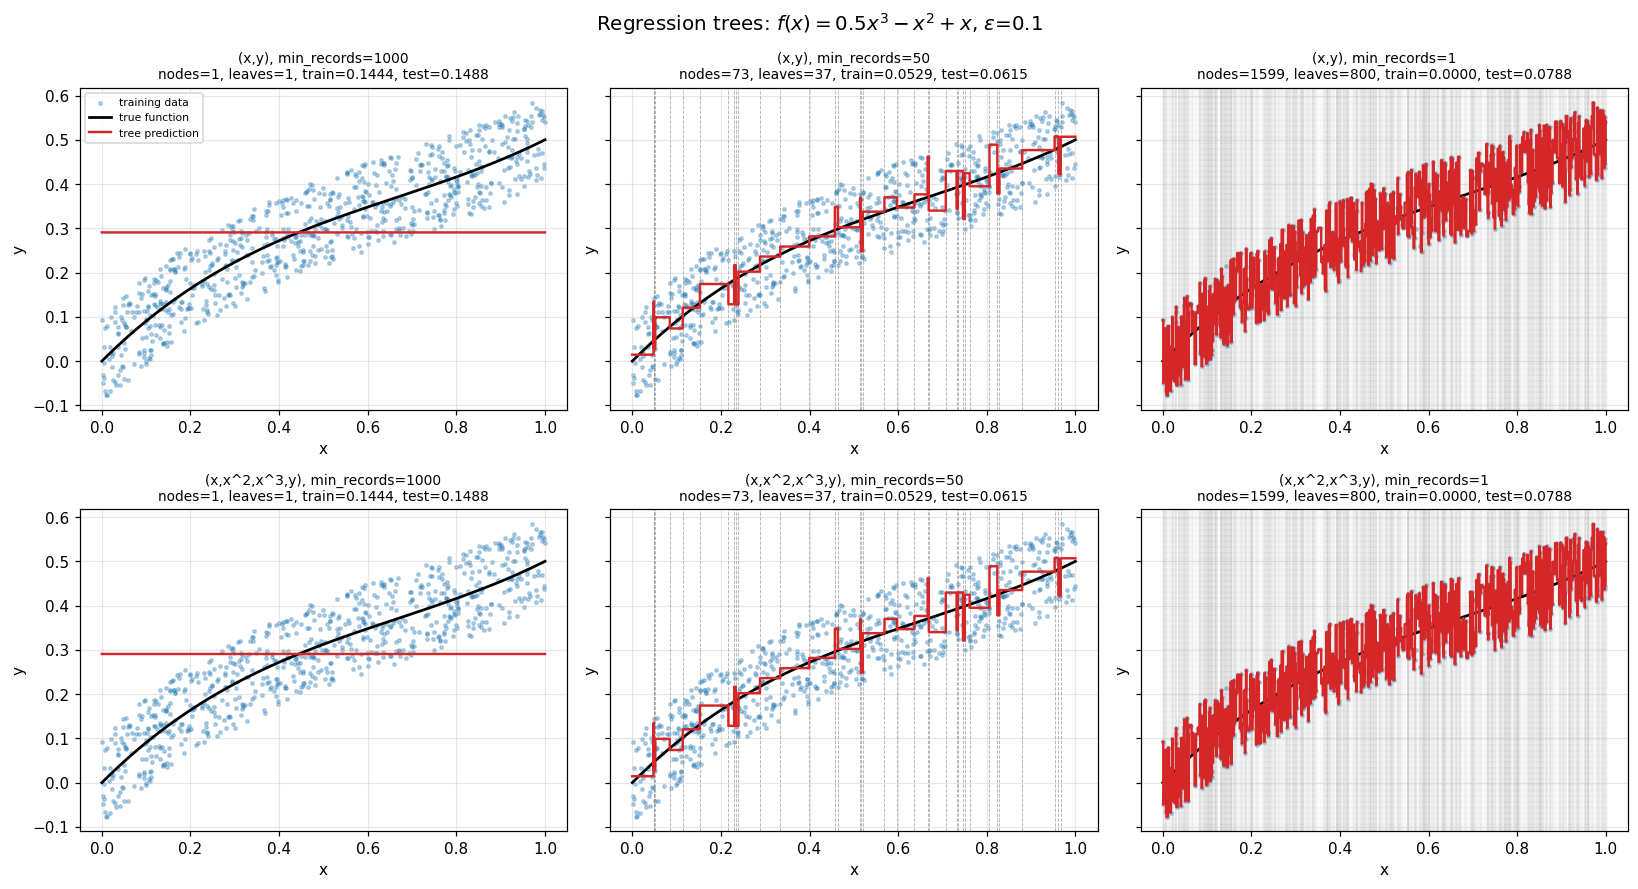

In [10]:
MIN_RECORDS = [1000, 50, 1]
tree_results = {}
for func_name in TRUE_FUNCS:
    for eps in NOISE_LEVELS:
        fig, axes = plt.subplots(2, 3, figsize=(15, 8.2), sharey=True)
        for r, (schema, feats) in enumerate(SCHEMAS.items()):
            Xtr, Xte, ytr, yte = make_split(func_name, eps, feats)
            for c, m in enumerate(MIN_RECORDS):
                tree = RegressionTree().fit(Xtr, ytr, min_records=m)
                rmse_tr = evaluate_model(tree.predict(Xtr), ytr)
                rmse_te = evaluate_model(tree.predict(Xte), yte)
                leaves = tree.leaf_sizes()
                split_feats = sorted({j for j, _ in tree.split_points()})
                tree_results[(schema, func_name, eps, m)] = dict(
                    train_rmse=rmse_tr, test_rmse=rmse_te, n_nodes=tree.n_nodes(), n_leaves=len(leaves),
                    depth=tree.depth(), leaf_min=int(min(leaves)), leaf_max=int(max(leaves)),
                    leaf_mean=float(np.mean(leaves)), split_features=split_feats)

                ax = axes[r, c]
                ax.scatter(Xtr[:, 0], ytr, s=5, alpha=0.3, label="training data")
                xg = np.linspace(*X_RANGE, 400)
                ax.plot(xg, TRUE_FUNCS[func_name](xg), "k-", lw=1.8, label="true function")
                tree.visualize(ax=ax, x_range=X_RANGE, feature_funcs=feats)
                ax.set_title(f"{schema}, min_records={m}\nnodes={tree.n_nodes()}, leaves={len(leaves)}, "
                             f"train={rmse_tr:.4f}, test={rmse_te:.4f}", fontsize=9)
                ax.set_xlabel("x"); ax.set_ylabel("y")
                if r == 0 and c == 0:
                    ax.legend(fontsize=7, loc="best")
                print(f"{func_name:6s} eps={eps:<5} {schema:15s} min_rec={m:<5} nodes={tree.n_nodes():5d} "
                      f"leaves={len(leaves):4d} depth={tree.depth():3d} leaf size [{min(leaves)},{max(leaves)}] "
                      f"train={rmse_tr:.5f} test={rmse_te:.5f} split cols={split_feats}")
        fig.suptitle(f"Regression trees: {TRUE_FUNC_TEX[func_name]}, $\\epsilon$={eps}", fontsize=13)
        fig.tight_layout()
        fig.savefig(f"{FIG_DIR}/q9_tree_{func_name}_eps{eps}.png", dpi=130, bbox_inches="tight")
        plt.show()

### Q10 – Trees vs. linear models (test RMSE)

In [11]:
print(f"{'func':6s} {'eps':5s} {'schema':15s} {'linear':>9s} {'tree m=1000':>12s} {'tree m=50':>10s} {'tree m=1':>9s}  winner")
q10 = []
for func_name in TRUE_FUNCS:
    for eps in NOISE_LEVELS:
        for schema in SCHEMAS:
            lr = lin_results[(schema, func_name, eps)]["test_rmse"]
            tr = {m: tree_results[(schema, func_name, eps, m)]["test_rmse"] for m in MIN_RECORDS}
            best_m = min(tr, key=tr.get)
            winner = "linear" if lr < tr[best_m] else f"tree(m={best_m})"
            q10.append(dict(func=func_name, eps=eps, schema=schema, linear=lr, **{f"tree_{m}": v for m, v in tr.items()}, winner=winner))
            print(f"{func_name:6s} {eps:<5} {schema:15s} {lr:9.5f} {tr[1000]:12.5f} {tr[50]:10.5f} {tr[1]:9.5f}  {winner}")

func   eps   schema             linear  tree m=1000  tree m=50  tree m=1  winner
linear 0.01  (x,y)             0.00574      0.60050    0.02530   0.00803  linear
linear 0.01  (x,x^2,x^3,y)     0.00574      0.60050    0.02530   0.00803  linear
linear 0.1   (x,y)             0.05739      0.60300    0.06361   0.07879  linear
linear 0.1   (x,x^2,x^3,y)     0.05744      0.60300    0.06361   0.07879  linear
cubic  0.01  (x,y)             0.02214      0.13685    0.00873   0.00788  tree(m=1)
cubic  0.01  (x,x^2,x^3,y)     0.00574      0.13685    0.00873   0.00788  linear
cubic  0.1   (x,y)             0.06287      0.14877    0.06155   0.07883  tree(m=50)
cubic  0.1   (x,x^2,x^3,y)     0.05744      0.14877    0.06155   0.07883  linear


### Q11 – Overfitting study: f(x) = sin(2πx), 200 records, ε = 0.2

160 training and 40 test records (the same fixed 80/20 split rule). Trees are trained for min_records ∈ {2, 4, …, 256}.

{'min_records': 2, 'train_rmse': 0.0, 'test_rmse': 0.1746044953760167, 'n_leaves': 160}
{'min_records': 4, 'train_rmse': 0.05674542981466738, 'test_rmse': 0.14745199591322544, 'n_leaves': 74}
{'min_records': 8, 'train_rmse': 0.08616719891855287, 'test_rmse': 0.13578213097697003, 'n_leaves': 37}
{'min_records': 16, 'train_rmse': 0.11245526519239488, 'test_rmse': 0.1635024253809233, 'n_leaves': 17}
{'min_records': 32, 'train_rmse': 0.13317035173623856, 'test_rmse': 0.1611376117956514, 'n_leaves': 10}
{'min_records': 64, 'train_rmse': 0.2551746013830314, 'test_rmse': 0.28629417224285075, 'n_leaves': 4}
{'min_records': 128, 'train_rmse': 0.30499216936864587, 'test_rmse': 0.34608229587218065, 'n_leaves': 2}
{'min_records': 256, 'train_rmse': 0.7388924283883771, 'test_rmse': 0.7496503295411813, 'n_leaves': 1}


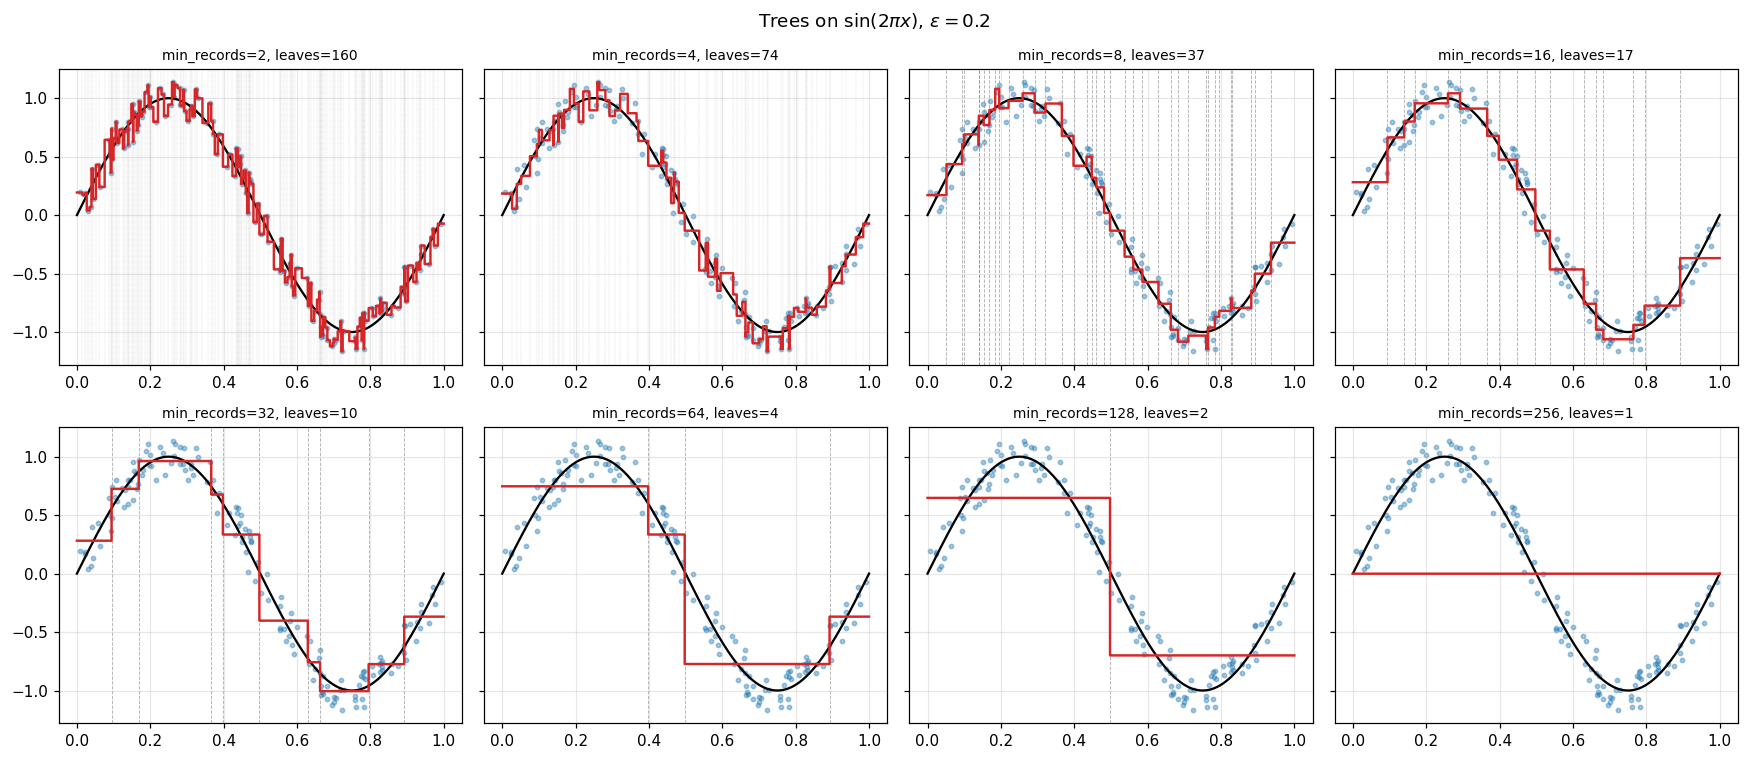

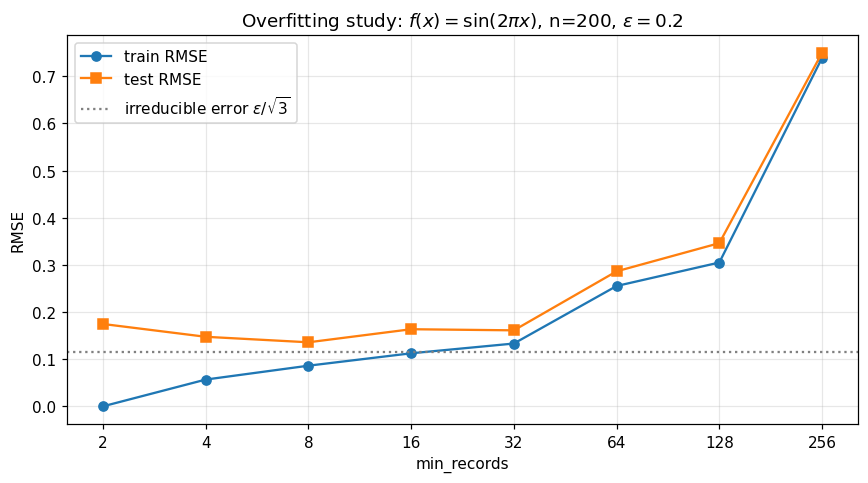

best min_records by test RMSE: 8


In [12]:
sin_f = lambda x: np.sin(2 * np.pi * x)
Xtr, Xte, ytr, yte = make_split(None, 0.2, [], n=200, true_func=sin_f)
MR = [2, 4, 8, 16, 32, 64, 128, 256]
q11 = []
fig_t, axes_t = plt.subplots(2, 4, figsize=(16, 7), sharey=True)
for i, m in enumerate(MR):
    tree = RegressionTree().fit(Xtr, ytr, min_records=m)
    q11.append(dict(min_records=m, train_rmse=evaluate_model(tree.predict(Xtr), ytr),
                    test_rmse=evaluate_model(tree.predict(Xte), yte), n_leaves=len(tree.leaf_sizes())))
    print(q11[-1])
    ax = axes_t.flat[i]
    ax.scatter(Xtr[:, 0], ytr, s=8, alpha=0.4)
    xg = np.linspace(0, 1, 400); ax.plot(xg, sin_f(xg), "k-", lw=1.5)
    tree.visualize(ax=ax)
    ax.set_title(f"min_records={m}, leaves={q11[-1]['n_leaves']}", fontsize=9)
fig_t.suptitle(r"Trees on $\sin(2\pi x)$, $\epsilon=0.2$"); fig_t.tight_layout()
fig_t.savefig(f"{FIG_DIR}/q11_trees.png", dpi=120, bbox_inches="tight"); plt.show()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(MR, [r["train_rmse"] for r in q11], "o-", label="train RMSE")
ax.plot(MR, [r["test_rmse"] for r in q11], "s-", label="test RMSE")
ax.axhline(0.2 / np.sqrt(3), color="gray", ls=":", label=r"irreducible error $\epsilon/\sqrt{3}$")
ax.set_xscale("log", base=2); ax.set_xticks(MR); ax.set_xticklabels(MR)
ax.set_xlabel("min_records"); ax.set_ylabel("RMSE")
ax.set_title(r"Overfitting study: $f(x)=\sin(2\pi x)$, n=200, $\epsilon=0.2$")
ax.legend(); fig.tight_layout()
fig.savefig(f"{FIG_DIR}/q11_overfitting.png", dpi=150, bbox_inches="tight")
plt.show()
best = min(q11, key=lambda r: r["test_rmse"])
print("best min_records by test RMSE:", best["min_records"])

## Part 6 – Save all results

All numbers above are stored in `results/results.json`.

In [13]:
k = lambda t: " | ".join(str(v) for v in t)
RESULTS = dict(
    linear={k(key): v for key, v in lin_results.items()},
    extrapolation={k(key): v for key, v in extrap.items()},
    irreducible={k(key): v for key, v in irreducible.items()},
    q7=dict(degrees=degrees, train=q7_train, test=q7_test),
    trees={k(key): v for key, v in tree_results.items()},
    q10=q10, q11=q11,
)
with open(f"{RES_DIR}/results.json", "w") as fh:
    json.dump(RESULTS, fh, indent=2)
print("saved", f"{RES_DIR}/results.json")

saved results/results.json
